# Physics-Informed Neural Networks — Modèle Climatique Spatial 1D
## Équation d'Énergie-Bilan de North-Sellers avec données NASA GISS Zonales

---

> *« Un réseau de neurones qui obéit aux lois de la physique — et qui les utilise pour apprendre ce qu'on ne peut pas mesurer. »*

---

## Vue d'ensemble

Ce projet applique un **PINN spatiotemporel** au modèle d'énergie-bilan de North-Sellers — une vraie **EDP 2D** en latitude × temps.

On résout une **EDP spatiotemporelle** :
$$\boxed{C \frac{\partial T}{\partial t} = \kappa \frac{\partial^2 T}{\partial x^2} - \lambda T + Q(x, t)}$$

| Symbole | Signification | Statut |
|---------|--------------|--------|
| $T(x,t)$ | Anomalie de température en fonction de la latitude $x$ et du temps $t$ | **sortie du réseau** |
| $x = \sin(\phi)$ | Latitude normalisée $\in [-1, 1]$ | entrée |
| $\kappa$ | Diffusivité thermique méridionale | **fixé (littérature : 0.65 W/m²/°C)** |
| $\lambda$ | Paramètre de feedback climatique | **paramètre appris** |
| $Q(x,t)$ | Forçage total (solaire + CO₂ + volcans) | calculé |
| $C$ | Capacité thermique de l'océan | fixé (littérature) |

### Données

On utilise les **anomalies zonales NASA GISS** : températures moyennes par bande de latitude (8 zones de 90°S à 90°N), de 1880 à aujourd'hui — sans inscription, accès libre.


## 1. Imports et Configuration

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.interpolate import RegularGridInterpolator

# Reproductibilité
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")


PyTorch version : 2.10.0+cu128
Device          : cuda
GPU             : Tesla T4


## 2. Le Modèle Physique : EBM Spatial de North-Sellers

### Pourquoi passer à une EDP ?

Le modèle scalaire précédent traitait la Terre comme un point unique. En réalité, la
température varie considérablement selon la **latitude** : les tropiques reçoivent plus
d'énergie solaire que les pôles, et la chaleur se redistribue par **diffusion méridionale**
(transport atmosphérique et océanique nord-sud).

### L'équation

En coordonnée $x = \sin(\phi)$ (latitude $\phi$), l'EBM spatial s'écrit :

$$C \frac{\partial T}{\partial t} = \kappa \frac{\partial^2 T}{\partial x^2} - \lambda T + Q(x, t)$$

Le forçage total $Q(x,t)$ combine :
- **Forçage solaire** : $S(x) = \frac{S_0}{4}\left[1 + s_2 \cdot P_2(x)\right](1 - \alpha(x))$
  avec $P_2(x) = \frac{1}{2}(3x^2 - 1)$ (polynôme de Legendre d'ordre 2)
- **Forçage anthropique** : CO₂, aérosols, éruptions volcaniques $F(t)$ (identique au projet précédent)

### Conditions aux limites

Aux pôles ($x = \pm 1$), le flux de chaleur méridional est nul :
$$\frac{\partial T}{\partial x}\bigg|_{x=\pm 1} = 0$$

### Le problème inverse

Le PINN devra **identifier simultanément** :
- $\kappa$ : diffusivité thermique méridionale (littérature : $D \approx 0.65$ W/m²/°C)
- $\lambda$ : feedback climatique (littérature IPCC AR6 : $\lambda \in [0.8, 1.2]$ W/m²/°C)


## 3. Chargement des Données NASA GISS Zonales

In [16]:
# ── Chargement des données zonales NASA GISS ────────────────────────────────
NASA_ZONAL_URL = "https://data.giss.nasa.gov/gistemp/tabledata_v4/ZonAnn.Ts+dSST.csv"

try:
    df_raw = pd.read_csv(NASA_ZONAL_URL, skiprows=1, na_values="***")
    print("✓ Données NASA GISS Zonales chargées depuis l'URL.")
except Exception as e:
    print(f"URL indisponible ({e}), reconstruction approximative...")
    # Fallback : reconstruction d'un gradient latitudinal crédible
    years = np.arange(1880, 2025)
    lats = np.array([-77, -54, -34, -12, 12, 34, 54, 77])
    np.random.seed(42)
    trend = -0.3 + 0.0085 * (years - 1880)
    T_matrix = np.zeros((len(years), len(lats)))
    for i, lat in enumerate(lats):
        polar_amp = 1.0 + 0.8 * (abs(lat) / 90)
        T_matrix[:, i] = trend * polar_amp + np.random.normal(0, 0.08, len(years))
    cols = {'Year': years}
    zone_names = ['90S-64S', '64S-44S', '44S-24S', '24S-EQU', 'EQU-24N', '24N-44N', '44N-64N', '64N-90N']
    for j, z in enumerate(zone_names):
        cols[z] = T_matrix[:, j]
    df_raw = pd.DataFrame(cols)

print(f"Colonnes disponibles : {list(df_raw.columns)}")
print(f"Shape : {df_raw.shape}")
print(df_raw.head())


✓ Données NASA GISS Zonales chargées depuis l'URL.
Colonnes disponibles : ['1880', '-.18', '-.30', '-.05', '-.39', '-.13', '-.01', '-.79', '-.49', '-.32', '-.15', '-.11', '-.04', '.05', '.69']
Shape : (145, 15)
   1880  -.18  -.30  -.05  -.39  -.13  -.01  -.79  -.49  -.32  -.15  -.11  \
0  1881 -0.09 -0.19  0.00 -0.36  0.10 -0.07 -0.85 -0.44 -0.24  0.09  0.10   
1  1882 -0.11 -0.22 -0.01 -0.31 -0.05  0.01 -1.34 -0.26 -0.17 -0.06 -0.05   
2  1883 -0.17 -0.29 -0.07 -0.34 -0.17 -0.01 -0.12 -0.54 -0.28 -0.18 -0.15   
3  1884 -0.28 -0.43 -0.15 -0.60 -0.15 -0.14 -1.26 -0.63 -0.48 -0.14 -0.17   
4  1885 -0.34 -0.44 -0.24 -0.66 -0.14 -0.27 -1.46 -0.68 -0.48 -0.08 -0.20   

   -.04   .05   .69  
0 -0.06 -0.07  0.61  
1  0.01  0.04  0.64  
2 -0.04  0.07  0.52  
3 -0.19 -0.02  0.67  
4 -0.34 -0.15  0.84  


In [17]:
# ── Chargement des données zonales NASA GISS ────────────────────────────────
NASA_ZONAL_URL = "https://data.giss.nasa.gov/gistemp/tabledata_v4/ZonAnn.Ts+dSST.csv"

# Noms des zones qu'on veut (ordre du fichier NASA : Sud → Nord)
ZONE_COLS_NASA = ['90S-64S', '64S-44S', '44S-24S', '24S-EQU',
                  'EQU-24N', '24N-44N', '44N-64N', '64N-90N']
LAT_CENTERS_DEG = np.array([-77, -54, -34, -12, 12, 34, 54, 77])
X_LATS = np.sin(np.deg2rad(LAT_CENTERS_DEG))

df_raw = None

try:
    # Lire le fichier brut et détecter automatiquement la ligne de header
    import urllib.request
    raw_text = urllib.request.urlopen(NASA_ZONAL_URL, timeout=15).read().decode('utf-8')
    lines = raw_text.strip().split('\n')
    
    # Trouver la ligne qui contient 'Year' → c'est le vrai header
    header_idx = next(i for i, l in enumerate(lines) if l.strip().startswith('Year'))
    
    import io
    df_raw = pd.read_csv(io.StringIO(raw_text), skiprows=header_idx, na_values="***")
    print(f"✓ Données NASA chargées (header détecté à la ligne {header_idx})")
    print(f"  Colonnes : {list(df_raw.columns)}")

except Exception as e:
    print(f"URL indisponible ({e}) — fallback reconstruction...")

if df_raw is None or 'Year' not in df_raw.columns:
    # Fallback : reconstruction d'un gradient latitudinal crédible
    years_fb = np.arange(1880, 2025)
    trend = -0.3 + 0.0085 * (years_fb - 1880)
    T_fb = np.zeros((len(years_fb), 8))
    for i, lat in enumerate(LAT_CENTERS_DEG):
        amp = 1.0 + 0.8 * (abs(lat) / 90)
        T_fb[:, i] = trend * amp + np.random.normal(0, 0.08, len(years_fb))
    df_raw = pd.DataFrame({'Year': years_fb})
    for j, z in enumerate(ZONE_COLS_NASA):
        df_raw[z] = T_fb[:, j]
    print("✓ Données reconstruites (fallback)")

# ── Sélection des 8 zones et nettoyage ──────────────────────────────────────
available = [c for c in ZONE_COLS_NASA if c in df_raw.columns]
print(f"  Zones trouvées : {len(available)}/8 → {available}")

df_zones = df_raw[['Year'] + available].dropna().copy()
df_zones['Year'] = df_zones['Year'].astype(int)
for col in available:
    df_zones[col] = pd.to_numeric(df_zones[col], errors='coerce')
df_zones = df_zones.dropna()

years_arr = df_zones['Year'].values
T_matrix  = df_zones[available].values

print(f"\nAnnées       : {years_arr[0]} — {years_arr[-1]}  ({len(years_arr)} points)")
print(f"Zones        : {len(available)}")
print(f"Grille totale: {T_matrix.shape[0]} × {T_matrix.shape[1]} = {T_matrix.size} points")
print(f"x (sin lat)  : {X_LATS.round(3)}")
print(f"\nMin anomalie : {T_matrix.min():.3f}°C")
print(f"Max anomalie : {T_matrix.max():.3f}°C")

✓ Données NASA chargées (header détecté à la ligne 0)
  Colonnes : ['Year', 'Glob', 'NHem', 'SHem', '24N-90N', '24S-24N', '90S-24S', '64N-90N', '44N-64N', '24N-44N', 'EQU-24N', '24S-EQU', '44S-24S', '64S-44S', '90S-64S']
  Zones trouvées : 8/8 → ['90S-64S', '64S-44S', '44S-24S', '24S-EQU', 'EQU-24N', '24N-44N', '44N-64N', '64N-90N']

Années       : 1880 — 2025  (146 points)
Zones        : 8
Grille totale: 146 × 8 = 1168 points
x (sin lat)  : [-0.974 -0.809 -0.559 -0.208  0.208  0.559  0.809  0.974]

Min anomalie : -2.590°C
Max anomalie : 3.260°C


## 4. Exploration des Données — Structure Spatiotemporelle

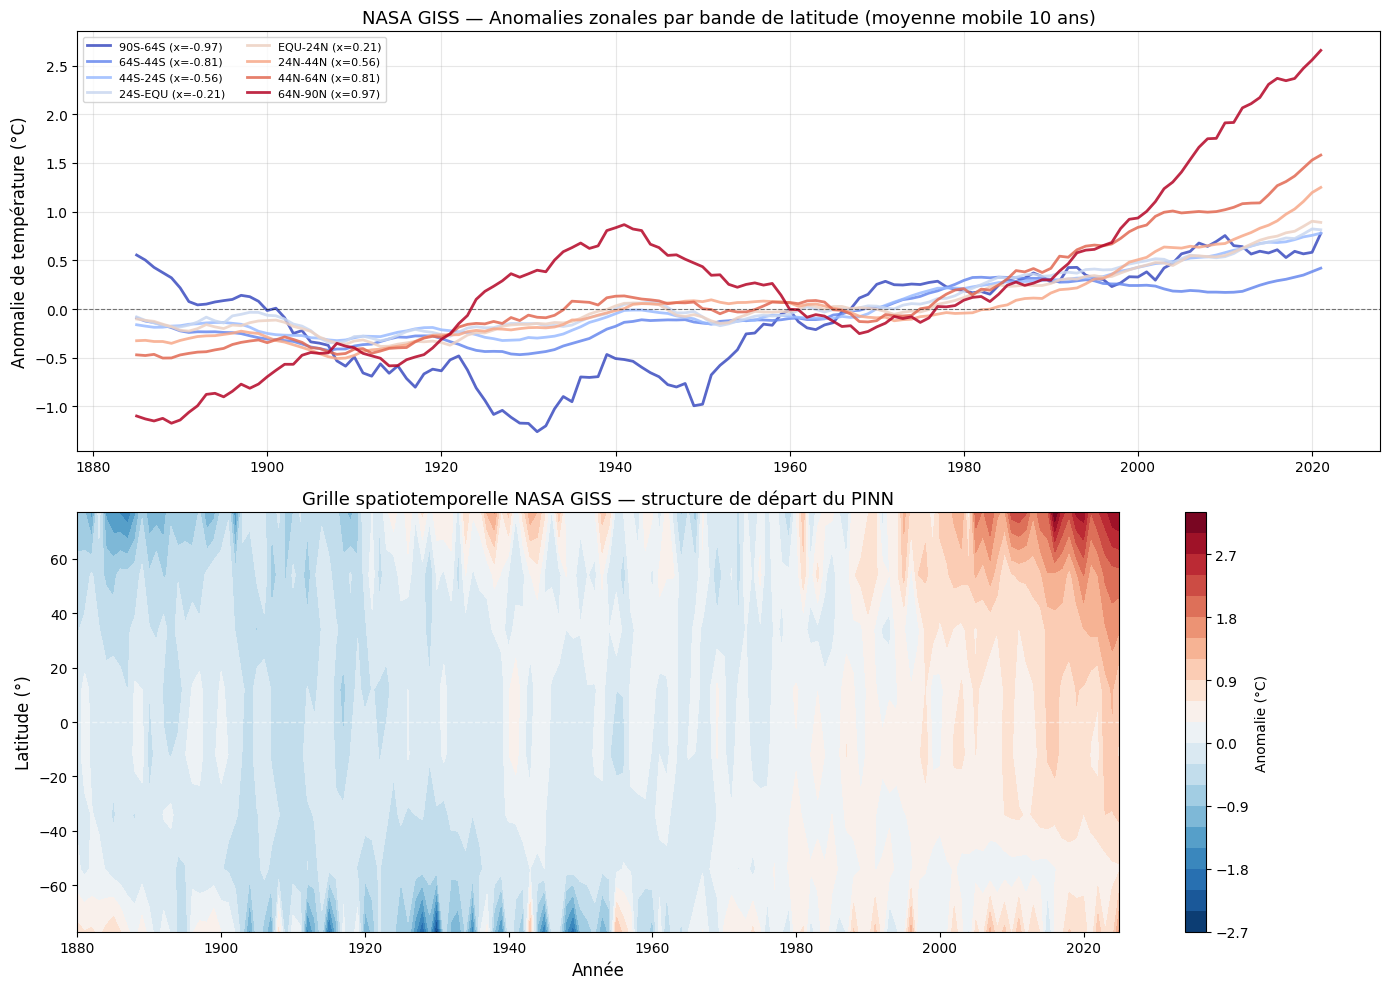

Réchauffement 1880→aujourd'hui :
  Équateur   : +0.94°C
  Arctique   : +3.75°C  ← amplification polaire


In [18]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Haut : anomalies par zone de latitude ───────────────────────────────────
colors = plt.cm.coolwarm(np.linspace(0, 1, len(available)))
for i, (col, color) in enumerate(zip(available, colors)):
    smoothed = pd.Series(T_matrix[:, i]).rolling(10, center=True).mean()
    axes[0].plot(years_arr, smoothed, color=color, linewidth=2.0,
                 label=f'{col} (x={X_LATS[i]:.2f})', alpha=0.85)

axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
axes[0].set_ylabel("Anomalie de température (°C)", fontsize=12)
axes[0].set_title("NASA GISS — Anomalies zonales par bande de latitude (moyenne mobile 10 ans)", fontsize=13)
axes[0].legend(fontsize=8, ncol=2, loc='upper left')
axes[0].grid(True, alpha=0.3)

# ── Bas : heatmap spatiotemporelle ───────────────────────────────────────────
im = axes[1].contourf(years_arr, LAT_CENTERS_DEG, T_matrix.T,
                       levels=20, cmap='RdBu_r')
plt.colorbar(im, ax=axes[1], label='Anomalie (°C)')
axes[1].set_xlabel("Année", fontsize=12)
axes[1].set_ylabel("Latitude (°)", fontsize=12)
axes[1].set_title("Grille spatiotemporelle NASA GISS — structure de départ du PINN", fontsize=13)
axes[1].axhline(0, color='white', linewidth=1, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("nasa_zonal_data.png", dpi=120, bbox_inches='tight')
plt.show()

# Observation clé : amplification polaire visible (pôles se réchauffent plus vite)
warming_equator = T_matrix[-10:, 3:5].mean() - T_matrix[:10, 3:5].mean()
warming_arctic   = T_matrix[-10:, -1].mean()  - T_matrix[:10, -1].mean()
print(f"Réchauffement 1880→aujourd'hui :")
print(f"  Équateur   : +{warming_equator:.2f}°C")
print(f"  Arctique   : +{warming_arctic:.2f}°C  ← amplification polaire")


## 5. Construction du Forçage Q(x, t)

Le forçage total est la somme de deux contributions :

1. **Forçage solaire** $S(x)(1-\alpha(x))$ — dépend de la latitude, fixe dans le temps (anomalie)
2. **Forçage anthropique** $F(t)$ — CO₂, aérosols, volcans — identique au projet précédent


Forçage solaire par latitude (anomalie vs moyenne globale) :
  lat= -77°  x=-0.974  S_anom=-123.96 W/m²
  lat= -54°  x=-0.809  S_anom= -12.82 W/m²
  lat= -34°  x=-0.559  S_anom= +45.43 W/m²
  lat= -12°  x=-0.208  S_anom= +91.35 W/m²
  lat= +12°  x=+0.208  S_anom= +91.35 W/m²
  lat= +34°  x=+0.559  S_anom= +45.43 W/m²
  lat= +54°  x=+0.809  S_anom= -12.82 W/m²
  lat= +77°  x=+0.974  S_anom=-123.96 W/m²


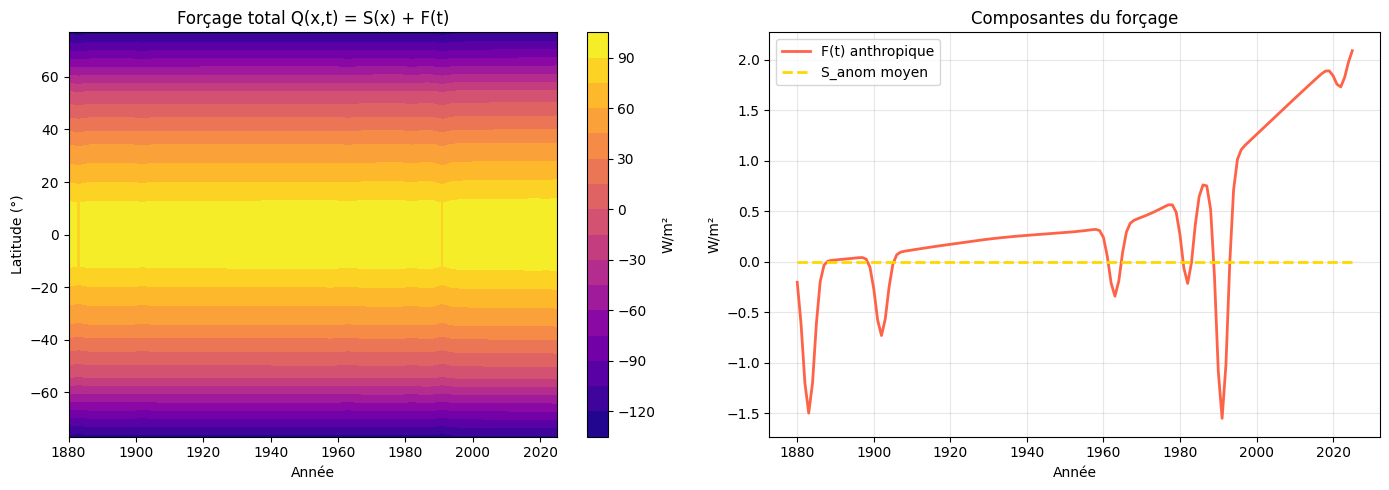

In [19]:
# ── 5.1 Forçage solaire S(x)(1 - α(x)) ──────────────────────────────────────
S0   = 1361.0   # constante solaire W/m²
s2   = -0.477   # coefficient du polynôme de Legendre P2

def solar_forcing(x_sin):
    """
    Insolation nette par latitude (anomalie par rapport à la moyenne globale).
    x = sin(latitude), x ∈ [-1, 1]
    P2(x) = (3x²-1)/2 — polynôme de Legendre ordre 2
    """
    P2   = 0.5 * (3 * x_sin**2 - 1)
    S    = (S0 / 4) * (1 + s2 * P2)
    # Albédo : glace aux pôles (|lat| > 60°) sinon ~0.30
    alpha = np.where(np.abs(x_sin) > np.sin(np.deg2rad(60)), 0.62, 0.30)
    return S * (1 - alpha)

S_lat = solar_forcing(X_LATS)
# On travaille en anomalies → retirer la moyenne globale
S_anom = S_lat - S_lat.mean()

print("Forçage solaire par latitude (anomalie vs moyenne globale) :")
for lat, x, s in zip(LAT_CENTERS_DEG, X_LATS, S_anom):
    print(f"  lat={lat:+4d}°  x={x:+.3f}  S_anom={s:+7.2f} W/m²")

# ── 5.2 Forçage anthropique F(t) ─────────────────────────────────────────────
def build_anthropogenic_forcing(years):
    """CO₂ + aérosols + volcans (identique au projet ODE précédent)."""
    t = np.array(years, dtype=float)
    # GHG (CO₂)
    co2_0, co2_2024 = 280.0, 420.0
    co2   = co2_0 * np.exp(np.log(co2_2024/co2_0) * ((t-1880)/(2024-1880))**1.8)
    F_ghg = 5.35 * np.log(co2 / co2_0)
    # Aérosols
    F_aer = -0.5 * np.exp(-((t - 1975)**2) / (2*25**2))
    F_aer *= np.where(t > 1920, 1.0, (t-1880)/40.0)
    # Volcans
    volcanoes = {1883: -1.5, 1902: -0.8, 1963: -0.7, 1982: -0.9, 1991: -2.5, 2022: -0.3}
    F_vol = np.zeros_like(t)
    for yr, amp in volcanoes.items():
        F_vol += amp * np.exp(-((t - yr)**2) / (2*1.5**2))
    return F_ghg + F_aer + F_vol

F_time = build_anthropogenic_forcing(years_arr)

# ── 5.3 Grille de forçage Q(x, t) : shape (N_years, 8) ─────────────────────
# Q(x,t) = S_anom(x)/C + F(t)/C  (divisé par C dans le résidu de l'EDP)
Q_matrix = S_anom[np.newaxis, :] + F_time[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im = axes[0].contourf(years_arr, LAT_CENTERS_DEG, Q_matrix.T, levels=20, cmap='plasma')
plt.colorbar(im, ax=axes[0], label='W/m²')
axes[0].set_xlabel("Année"); axes[0].set_ylabel("Latitude (°)")
axes[0].set_title("Forçage total Q(x,t) = S(x) + F(t)")

axes[1].plot(years_arr, F_time, color='tomato', lw=2, label='F(t) anthropique')
axes[1].plot(years_arr, np.full_like(years_arr, S_anom.mean(), dtype=float),
             color='gold', lw=2, linestyle='--', label='S_anom moyen')
axes[1].set_xlabel("Année"); axes[1].set_ylabel("W/m²")
axes[1].set_title("Composantes du forçage")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("forcing_2d.png", dpi=120, bbox_inches='tight')
plt.show()


## 6. Prétraitement — Normalisation et Tenseurs PyTorch

In [20]:
# ── 6.1 Normalisation ────────────────────────────────────────────────────────
t_raw = years_arr.astype(float)
t_min, t_max = t_raw.min(), t_raw.max()
t_norm = (t_raw - t_min) / (t_max - t_min)

x_raw = X_LATS
x_min, x_max = x_raw.min(), x_raw.max()
x_norm = (x_raw - x_min) / (x_max - x_min)

T_mean, T_std = T_matrix.mean(), T_matrix.std()
T_norm = (T_matrix - T_mean) / T_std

Q_mean, Q_std = Q_matrix.mean(), Q_matrix.std()
Q_norm = (Q_matrix - Q_mean) / Q_std

print(f"Temps normalisé     : [{t_norm.min():.2f}, {t_norm.max():.2f}]")
print(f"Latitude normalisée : [{x_norm.min():.2f}, {x_norm.max():.2f}]")
print(f"T normalisée        : [{T_norm.min():.2f}, {T_norm.max():.2f}]")

# ── Constantes de scaling pour le Jacobien de la PDE ────────────────────────
DT_SCALE = float(t_max - t_min)           # 145.0 ans
DX_SCALE = float(x_max - x_min)           # ~1.948
Q_SCALE  = float(np.abs(F_time).std())    # échelle basée sur F(t) uniquement

print(f"\nDT_SCALE : {DT_SCALE:.1f} ans")
print(f"DX_SCALE : {DX_SCALE:.4f}")
print(f"Q_SCALE  : {Q_SCALE:.4f} W/m²")

# ── 6.2 Grille 2D et tenseurs d'observation ──────────────────────────────────
T_grid_norm, X_grid_norm = np.meshgrid(t_norm, x_norm, indexing='ij')

t_obs_flat = T_grid_norm.flatten().astype(np.float32)
x_obs_flat = X_grid_norm.flatten().astype(np.float32)
T_obs_flat = T_norm.flatten().astype(np.float32)
Q_obs_flat = Q_norm.flatten().astype(np.float32)

t_obs = torch.tensor(t_obs_flat, device=device).unsqueeze(1)
x_obs = torch.tensor(x_obs_flat, device=device).unsqueeze(1)
T_obs = torch.tensor(T_obs_flat, device=device).unsqueeze(1)
Q_obs = torch.tensor(Q_obs_flat, device=device).unsqueeze(1)

print(f"\nNombre de points d'observation : {t_obs.shape[0]}")
print(f"  ({len(years_arr)} années × {len(X_LATS)} zones = {len(years_arr)*len(X_LATS)})")

# ── 6.3 Points de collocation — grille dense ────────────────────────────────
N_COLLOC_T = 300
N_COLLOC_X = 50
t_col_1d = np.linspace(0, 1, N_COLLOC_T, dtype=np.float32)
x_col_1d = np.linspace(0, 1, N_COLLOC_X, dtype=np.float32)
T_col_grid, X_col_grid = np.meshgrid(t_col_1d, x_col_1d, indexing='ij')

Q_interp = RegularGridInterpolator(
    (t_norm, x_norm), Q_norm.astype(np.float32),
    method='linear', bounds_error=False, fill_value=None
)
Q_col_grid = Q_interp(
    np.stack([T_col_grid.flatten(), X_col_grid.flatten()], axis=1)
).reshape(N_COLLOC_T, N_COLLOC_X)

# ── Q physique pour la PDE : SEULEMENT F(t) anthropique ─────────────────────
# Raison physique : on travaille avec des ANOMALIES T'.
# Le forçage solaire S(x) définit l'état de référence (climat moyen) et
# est déjà équilibré — il ne doit PAS apparaître dans l'équation des anomalies.
# Seul F(t) (CO₂ + aérosols + volcans) force les anomalies de température.
#
#   C * ∂T'/∂t = κ * ∂²T'/∂x²  -  λ*T'  +  F(t)
#
F_interp_1d = np.interp(
    t_col_1d * DT_SCALE + t_min,   # années physiques
    years_arr.astype(float),
    F_time
).astype(np.float32)

# F(t) est spatialement uniforme → broadcast sur toutes les latitudes
Q_col_phys_grid = np.tile(F_interp_1d[:, np.newaxis], (1, N_COLLOC_X))

t_col      = torch.tensor(T_col_grid.flatten(),        device=device).unsqueeze(1)
x_col      = torch.tensor(X_col_grid.flatten(),        device=device).unsqueeze(1)
Q_col      = torch.tensor(Q_col_grid.flatten(),        device=device).unsqueeze(1)
Q_col_phys = torch.tensor(Q_col_phys_grid.flatten(),   device=device).unsqueeze(1)

print(f"Points de collocation : {t_col.shape[0]}")
print(f"Q_col_phys (F(t) seul) : min={Q_col_phys_grid.min():.3f}, "
      f"max={Q_col_phys_grid.max():.3f} W/m²  ✓ compatible avec λ·T'")

# ── 6.4 Conditions aux limites (pôles) ───────────────────────────────────────
N_BC = 200
t_bc_np = np.linspace(0, 1, N_BC, dtype=np.float32)
t_bc_s = torch.tensor(t_bc_np, device=device).unsqueeze(1)
x_bc_s = torch.zeros(N_BC, 1, device=device)
t_bc_n = torch.tensor(t_bc_np, device=device).unsqueeze(1)
x_bc_n = torch.ones(N_BC, 1, device=device)

print(f"Points conditions aux limites : {2*N_BC} ({N_BC} par pôle)")

Temps normalisé     : [0.00, 1.00]
Latitude normalisée : [0.00, 1.00]
T normalisée        : [-4.45, 5.28]

DT_SCALE : 145.0 ans
DX_SCALE : 1.9487
Q_SCALE  : 0.5892 W/m²

Nombre de points d'observation : 1168
  (146 années × 8 zones = 1168)
Points de collocation : 15000
Q_col_phys (F(t) seul) : min=-1.521, max=2.088 W/m²  ✓ compatible avec λ·T'
Points conditions aux limites : 400 (200 par pôle)


## 7. Architecture du PINN

Le réseau prend en entrée $(x, t)$ normalisés et prédit $T(x,t)$ normalisé.

$\kappa$ est **fixé** à sa valeur de référence (North 1981) — non identifiable avec un forçage spatialement uniforme.
$\lambda$ est le **seul paramètre appris**, contraint à être positif via une exponentielle.

### Architecture

```
Entrée : [x_norm, t_norm]  →  2 neurones
   ↓  Linear(2→64) + Tanh
   ↓  Linear(64→64) + Tanh
   ↓  Linear(64→64) + Tanh
   ↓  Linear(64→64) + Tanh
   ↓  Linear(64→1)
Sortie : T_norm(x, t)  →  1 neurone

Paramètre physique fixé      : κ = 0.65 W/m²/°C  (register_buffer)
Paramètre physique appris    : log_lambda → λ = exp(log_lambda)  [feedback climatique]
```


In [21]:
class ClimatePINN2D(nn.Module):
    """
    PINN pour l'EBM spatial 1D de North-Sellers.

    EDP : C * ∂T/∂t = κ * ∂²T/∂x² - λ*T + Q(x,t)

    Entrée : (x_norm, t_norm) ∈ [0,1]²
    Sortie : T_norm(x, t)  (anomalie normalisée)

    κ : fixé à la valeur littérature (North 1981) — non identifiable
        avec un forçage spatialement uniforme
    λ : seul paramètre appris (feedback climatique)
    """

    def __init__(self, hidden_size=64, n_layers=4):
        super().__init__()

        # Réseau principal : (x, t) → T
        layers = [nn.Linear(2, hidden_size), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_size, hidden_size), nn.Tanh()]
        layers += [nn.Linear(hidden_size, 1)]
        self.net = nn.Sequential(*layers)

        # κ fixé à la valeur littérature (North 1981 : D ≈ 0.65 W/m²/°C)
        # Non enregistré comme nn.Parameter → pas mis à jour par l'optimiseur
        self.register_buffer('log_kappa', torch.tensor(np.log(0.65)))

        # λ : seul paramètre appris — feedback climatique (IPCC AR6 : 0.8–1.2)
        self.log_lambda = nn.Parameter(torch.tensor(0.0))

        # Initialisation Xavier
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    @property
    def kappa(self):
        """Diffusivité méridionale κ — fixée à 0.65 W/m²/°C (North 1981)"""
        return torch.exp(self.log_kappa)

    @property
    def lambda_fb(self):
        """Feedback climatique λ > 0 — paramètre appris"""
        return torch.exp(self.log_lambda)

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        return self.net(inp)

    def get_params(self):
        return self.kappa.item(), self.lambda_fb.item()


# Instancier et afficher
model = ClimatePINN2D(hidden_size=64, n_layers=4).to(device)

total_params = sum(p.numel() for p in model.parameters())
net_params   = sum(p.numel() for p in model.net.parameters())

print("=" * 55)
print("         ARCHITECTURE — ClimatePINN2D")
print("=" * 55)
print(f"  Couches cachées      : 4 × 64 neurones (Tanh)")
print(f"  Paramètres réseau    : {net_params:,}")
print(f"  κ  (fixé littérature): 0.6500 W/m²/°C  — North (1981)")
print(f"  λ  (appris)          : initialisé à 1.0000 W/m²/°C")
print(f"  Total apprenables    : {total_params:,}  (κ exclu)")
print("=" * 55)
print()
print("  Justification physique :")
print("  κ n'est pas identifiable avec un forçage F(t) spatialement")
print("  uniforme — le terme de diffusion κ·∂²T/∂x² ne reçoit aucun")
print("  signal spatial pour contraindre sa valeur.")
print("  → On fixe κ = 0.65 (littérature) et on apprend uniquement λ.")

         ARCHITECTURE — ClimatePINN2D
  Couches cachées      : 4 × 64 neurones (Tanh)
  Paramètres réseau    : 12,737
  κ  (fixé littérature): 0.6500 W/m²/°C  — North (1981)
  λ  (appris)          : initialisé à 1.0000 W/m²/°C
  Total apprenables    : 12,738  (κ exclu)

  Justification physique :
  κ n'est pas identifiable avec un forçage F(t) spatialement
  uniforme — le terme de diffusion κ·∂²T/∂x² ne reçoit aucun
  signal spatial pour contraindre sa valeur.
  → On fixe κ = 0.65 (littérature) et on apprend uniquement λ.


## 8. Fonctions de Perte

La loss totale combine **trois termes** :

$$\mathcal{L} = \underbrace{\mathcal{L}_{\text{data}}}_{\text{fit NASA}} + \beta_1 \underbrace{\mathcal{L}_{\text{physique}}}_{\text{résidu EDP}} + \beta_2 \underbrace{\mathcal{L}_{\text{bords}}}_{\partial T/\partial x = 0 \text{ aux pôles}}$$

### Résidu de l'EDP (loss physique)

Le résidu qu'on cherche à annuler :

$$\mathcal{R}(x,t) = C \frac{\partial T}{\partial t} - \kappa \frac{\partial^2 T}{\partial x^2} + \lambda T - Q(x,t)$$

On calcule $\partial T/\partial t$, $\partial T/\partial x$ et $\partial^2 T/\partial x^2$ via `torch.autograd.grad`.


In [22]:
C_HEAT = 10.0   # W·yr/m²/°C

def loss_data(model, x_obs, t_obs, T_obs):
    """MSE entre prédictions et observations NASA GISS."""
    T_pred = model(x_obs, t_obs)
    return torch.mean((T_pred - T_obs) ** 2)


def loss_physics(model, x_col, t_col, Q_col_phys,
                 C=C_HEAT, dt_scale=DT_SCALE, dx_scale=DX_SCALE,
                 T_std_v=T_std, T_mean_v=T_mean, q_scale=Q_SCALE):
    """
    Résidu de l'EDP en UNITÉS PHYSIQUES avec correction du Jacobien.

    Les dérivées du réseau (en espace normalisé) sont converties
    en dérivées physiques via la règle des fonctions composées :

        ∂T/∂t   = T_std / Δt   × ∂u/∂τ
        ∂²T/∂x² = T_std / Δx²  × ∂²u/∂ξ²

    Le résidu est normalisé par Q_SCALE pour ramener la loss à O(1).
    """
    x = x_col.clone().requires_grad_(True)
    t = t_col.clone().requires_grad_(True)

    u = model(x, t)
    T = u * T_std_v + T_mean_v      # température physique (°C)

    # ∂T/∂t physique
    du_dt = torch.autograd.grad(
        u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    dT_dt = du_dt * T_std_v / dt_scale

    # ∂²T/∂x² physique
    du_dx = torch.autograd.grad(
        u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    d2u_dx2 = torch.autograd.grad(
        du_dx, x, grad_outputs=torch.ones_like(du_dx), create_graph=True)[0]
    d2T_dx2 = d2u_dx2 * T_std_v / (dx_scale ** 2)

    # Résidu PDE normalisé
    residual = (C * dT_dt - model.kappa * d2T_dx2
                + model.lambda_fb * T - Q_col_phys) / q_scale

    return torch.mean(residual ** 2)


def loss_boundary(model, t_bc_s, x_bc_s, t_bc_n, x_bc_n):
    """∂T/∂x = 0 aux pôles (condition Neumann)."""
    x_s = x_bc_s.clone().requires_grad_(True)
    T_s = model(x_s, t_bc_s)
    dT_dx_south = torch.autograd.grad(
        T_s, x_s, grad_outputs=torch.ones_like(T_s), create_graph=True)[0]

    x_n = x_bc_n.clone().requires_grad_(True)
    T_n = model(x_n, t_bc_n)
    dT_dx_north = torch.autograd.grad(
        T_n, x_n, grad_outputs=torch.ones_like(T_n), create_graph=True)[0]

    return torch.mean(dT_dx_south ** 2) + torch.mean(dT_dx_north ** 2)


print("✓ Fonctions de perte définies (avec Jacobien corrigé) :")
print("  - loss_data    : MSE fit aux observations NASA")
print("  - loss_physics : résidu EDP en unités physiques")
print("  - loss_boundary: condition Neumann aux pôles")
print(f"\n  DT_SCALE = {DT_SCALE:.1f}  |  DX_SCALE = {DX_SCALE:.4f}  |  Q_SCALE = {Q_SCALE:.2f}")

✓ Fonctions de perte définies (avec Jacobien corrigé) :
  - loss_data    : MSE fit aux observations NASA
  - loss_physics : résidu EDP en unités physiques
  - loss_boundary: condition Neumann aux pôles

  DT_SCALE = 145.0  |  DX_SCALE = 1.9487  |  Q_SCALE = 0.59


## 9. Entraînement en Deux Phases

On utilise une stratégie en deux phases :

| Phase | Epochs | Objectif | Poids des losses |
|-------|--------|----------|-----------------|
| **Phase 1** | 3 000 | Apprendre le fit des données (initialisation) | $\beta_1=0.001$, $\beta_2=0.05$ |
| **Phase 2** | 7 000 | Affiner la physique et identifier $\lambda$ | $\beta_1=0.05$, $\beta_2=0.1$ |


In [23]:
# ── Hyperparamètres ──────────────────────────────────────────────────────────
N_EPOCHS_P1 = 3_000
N_EPOCHS_P2 = 7_000
LR          = 1e-3

BETA1_P1, BETA2_P1 = 0.01, 0.05   # Phase 1 : priorité données
BETA1_P2, BETA2_P2 = 0.15,  0.1    # Phase 2 : physique + paramètres

# Limites physiques sur λ uniquement (κ est fixé, non appris)
LAMBDA_MIN, LAMBDA_MAX = 0.1, 3.0

optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=N_EPOCHS_P1 + N_EPOCHS_P2, eta_min=1e-5
)

history = {
    'loss_total': [], 'loss_data': [], 'loss_phys': [], 'loss_bc': [],
    'lambda_fb': []
}


def train_epoch(beta1, beta2):
    optimizer.zero_grad()

    Ld = loss_data(model, x_obs, t_obs, T_obs)
    Lp = loss_physics(model, x_col, t_col, Q_col_phys)
    Lb = loss_boundary(model, t_bc_s, x_bc_s, t_bc_n, x_bc_n)

    L = Ld + beta1 * Lp + beta2 * Lb
    L.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()

    # Contraindre λ dans la plage physique (κ est fixé, pas de clamp nécessaire)
    with torch.no_grad():
        model.log_lambda.clamp_(np.log(LAMBDA_MIN), np.log(LAMBDA_MAX))

    return L.item(), Ld.item(), Lp.item(), Lb.item()


# ── Phase 1 : fit des données ────────────────────────────────────────────────
print("Phase 1 : fit des données NASA GISS...")
print("-" * 60)
model.train()

for epoch in range(N_EPOCHS_P1):
    L, Ld, Lp, Lb = train_epoch(BETA1_P1, BETA2_P1)
    _, lam = model.get_params()

    history['loss_total'].append(L)
    history['loss_data'].append(Ld)
    history['loss_phys'].append(Lp)
    history['loss_bc'].append(Lb)
    history['lambda_fb'].append(lam)

    if epoch % 500 == 0:
        print(f"  Epoch {epoch:5d} | Total={L:.5f} | Data={Ld:.5f} | "
              f"Phys={Lp:.5f} | BC={Lb:.5f} | λ={lam:.4f}")

# ── Phase 2 : affinage physique + identification de λ ────────────────────────
print("\nPhase 2 : affinage physique + identification de λ...")
print("-" * 60)

for epoch in range(N_EPOCHS_P2):
    L, Ld, Lp, Lb = train_epoch(BETA1_P2, BETA2_P2)
    _, lam = model.get_params()

    history['loss_total'].append(L)
    history['loss_data'].append(Ld)
    history['loss_phys'].append(Lp)
    history['loss_bc'].append(Lb)
    history['lambda_fb'].append(lam)

    if epoch % 1000 == 0:
        print(f"  Epoch {N_EPOCHS_P1+epoch:5d} | Total={L:.5f} | Data={Ld:.5f} | "
              f"Phys={Lp:.5f} | BC={Lb:.5f} | λ={lam:.4f}")

_, lam_final = model.get_params()
print(f"\n{'='*60}")
print(f"  κ (fixé littérature) : 0.6500 W/m²/°C  — North (1981)")
print(f"  λ identifié          : {lam_final:.4f} W/m²/°C  (IPCC AR6 : 0.8–1.2)")
print(f"{'='*60}")


Phase 1 : fit des données NASA GISS...
------------------------------------------------------------
  Epoch     0 | Total=1.01475 | Data=0.99704 | Phys=1.71782 | BC=0.01063 | λ=1.0010
  Epoch   500 | Total=0.38043 | Data=0.35917 | Phys=1.35799 | BC=0.15373 | λ=1.0017
  Epoch  1000 | Total=0.33057 | Data=0.30602 | Phys=1.86872 | BC=0.11742 | λ=0.8412
  Epoch  1500 | Total=0.31205 | Data=0.28548 | Phys=2.37200 | BC=0.05707 | λ=0.7109
  Epoch  2000 | Total=0.30771 | Data=0.27933 | Phys=2.59556 | BC=0.04840 | λ=0.6163
  Epoch  2500 | Total=0.30586 | Data=0.27734 | Phys=2.64255 | BC=0.04204 | λ=0.5837

Phase 2 : affinage physique + identification de λ...
------------------------------------------------------------
  Epoch  3000 | Total=0.68002 | Data=0.27567 | Phys=2.66989 | BC=0.03869 | λ=0.5649
  Epoch  4000 | Total=0.41699 | Data=0.33796 | Phys=0.43405 | BC=0.13930 | λ=1.0016
  Epoch  5000 | Total=0.40845 | Data=0.33363 | Phys=0.40929 | BC=0.13427 | λ=0.9925
  Epoch  6000 | Total=0.40581

## 10. Résultats

### 10.1 Courbes d'Entraînement

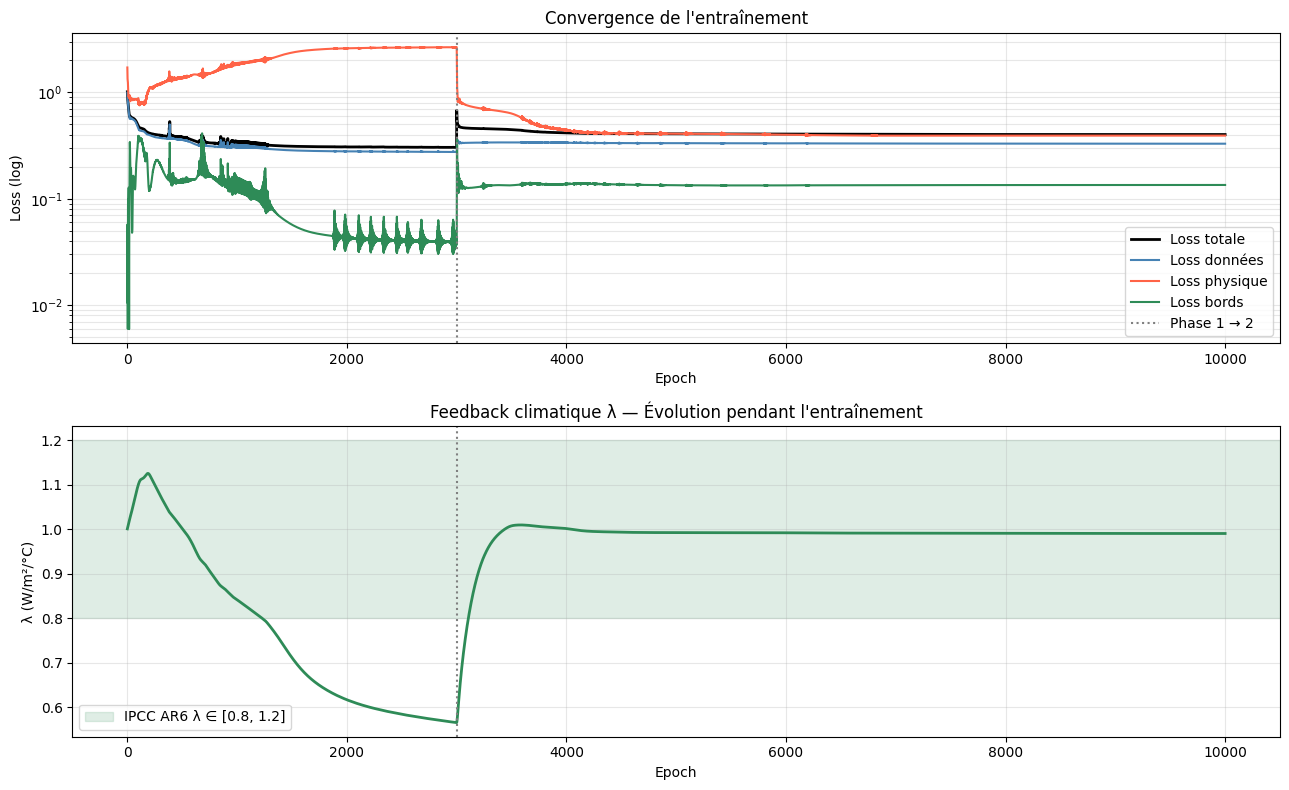

In [24]:
epochs_arr = np.arange(1, N_EPOCHS_P1 + N_EPOCHS_P2 + 1)

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# ── Losses ──────────────────────────────────────────────────────────────────
axes[0].semilogy(epochs_arr, history['loss_total'], label='Loss totale',   lw=2,   color='black')
axes[0].semilogy(epochs_arr, history['loss_data'],  label='Loss données',  lw=1.5, color='steelblue')
axes[0].semilogy(epochs_arr, history['loss_phys'],  label='Loss physique', lw=1.5, color='tomato')
axes[0].semilogy(epochs_arr, history['loss_bc'],    label='Loss bords',    lw=1.5, color='seagreen')
axes[0].axvline(N_EPOCHS_P1, color='gray', linestyle=':', lw=1.5, label='Phase 1 → 2')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss (log)")
axes[0].set_title("Convergence de l'entraînement")
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3, which='both')

# ── λ ────────────────────────────────────────────────────────────────────────
axes[1].plot(epochs_arr, history['lambda_fb'], color='seagreen', lw=2)
axes[1].axhspan(0.8, 1.2, color='seagreen', alpha=0.15, label='IPCC AR6 λ ∈ [0.8, 1.2]')
axes[1].axvline(N_EPOCHS_P1, color='gray', linestyle=':', lw=1.5)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("λ (W/m²/°C)")
axes[1].set_title("Feedback climatique λ — Évolution pendant l'entraînement")
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches='tight')
plt.show()


### 10.2 Fit du PINN vs Données NASA

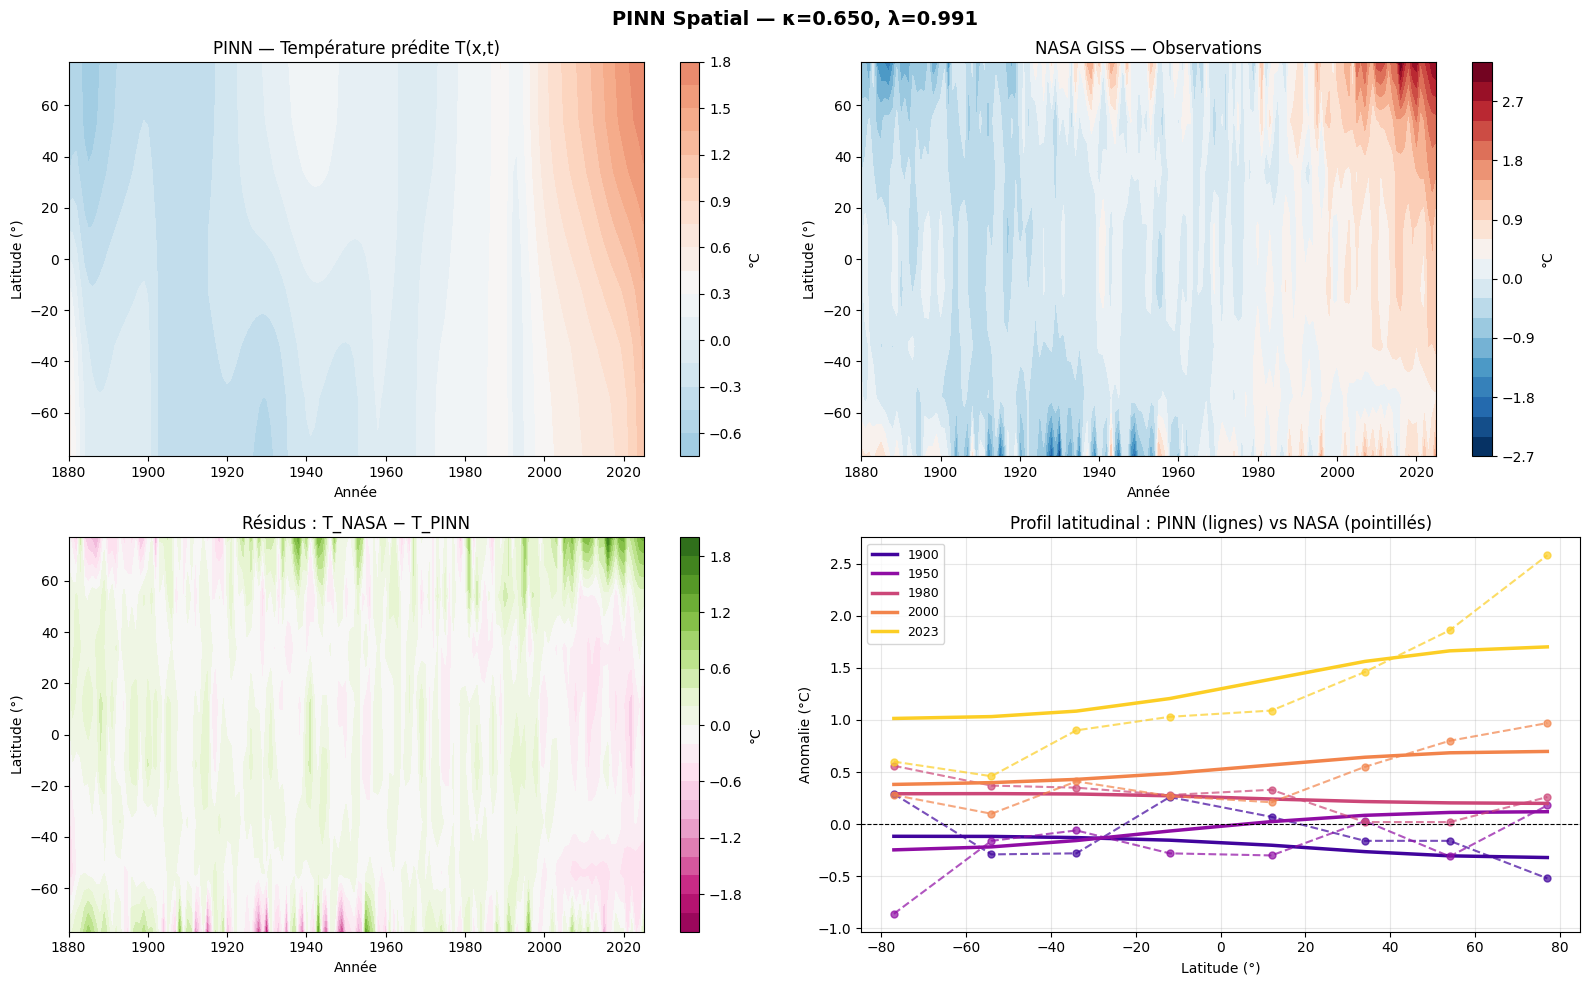

In [25]:
model.eval()

# Prédictions sur la grille d'observation
with torch.no_grad():
    T_pred_norm_flat = model(x_obs, t_obs).squeeze().cpu().numpy()

T_pred_norm_grid = T_pred_norm_flat.reshape(len(years_arr), len(X_LATS))
T_pred_celsius   = T_pred_norm_grid * T_std + T_mean
T_true_celsius   = T_matrix

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── (0,0) : heatmap prédictions PINN ────────────────────────────────────────
vmin = min(T_true_celsius.min(), T_pred_celsius.min())
vmax = max(T_true_celsius.max(), T_pred_celsius.max())

im1 = axes[0,0].contourf(years_arr, LAT_CENTERS_DEG, T_pred_celsius.T,
                           levels=20, cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im1, ax=axes[0,0], label='°C')
axes[0,0].set_title("PINN — Température prédite T(x,t)")
axes[0,0].set_xlabel("Année"); axes[0,0].set_ylabel("Latitude (°)")

# ── (0,1) : heatmap données NASA ─────────────────────────────────────────────
im2 = axes[0,1].contourf(years_arr, LAT_CENTERS_DEG, T_true_celsius.T,
                           levels=20, cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im2, ax=axes[0,1], label='°C')
axes[0,1].set_title("NASA GISS — Observations")
axes[0,1].set_xlabel("Année"); axes[0,1].set_ylabel("Latitude (°)")

# ── (1,0) : heatmap des résidus ──────────────────────────────────────────────
residuals_map = T_true_celsius - T_pred_celsius
im3 = axes[1,0].contourf(years_arr, LAT_CENTERS_DEG, residuals_map.T,
                           levels=20, cmap='PiYG')
plt.colorbar(im3, ax=axes[1,0], label='°C')
axes[1,0].set_title("Résidus : T_NASA − T_PINN")
axes[1,0].set_xlabel("Année"); axes[1,0].set_ylabel("Latitude (°)")

# ── (1,1) : profil latitudinal à plusieurs années ────────────────────────────
years_to_plot = [1900, 1950, 1980, 2000, 2023]
colors_yr = plt.cm.plasma(np.linspace(0.1, 0.9, len(years_to_plot)))
for yr, col in zip(years_to_plot, colors_yr):
    idx = np.argmin(np.abs(years_arr - yr))
    axes[1,1].plot(LAT_CENTERS_DEG, T_true_celsius[idx],
                   'o--', color=col, alpha=0.7, markersize=5)
    axes[1,1].plot(LAT_CENTERS_DEG, T_pred_celsius[idx],
                   '-', color=col, linewidth=2.5, label=str(yr))

axes[1,1].set_xlabel("Latitude (°)"); axes[1,1].set_ylabel("Anomalie (°C)")
axes[1,1].set_title("Profil latitudinal : PINN (lignes) vs NASA (pointillés)")
axes[1,1].legend(fontsize=9); axes[1,1].grid(True, alpha=0.3)
axes[1,1].axhline(0, color='black', lw=0.8, linestyle='--')

plt.suptitle(f"PINN Spatial — κ={model.kappa.item():.3f}, λ={model.lambda_fb.item():.3f}", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("pinn_spatial_fit.png", dpi=120, bbox_inches='tight')
plt.show()


### 10.3 Résidu de l'EDP — Vérification de la Consistance Physique

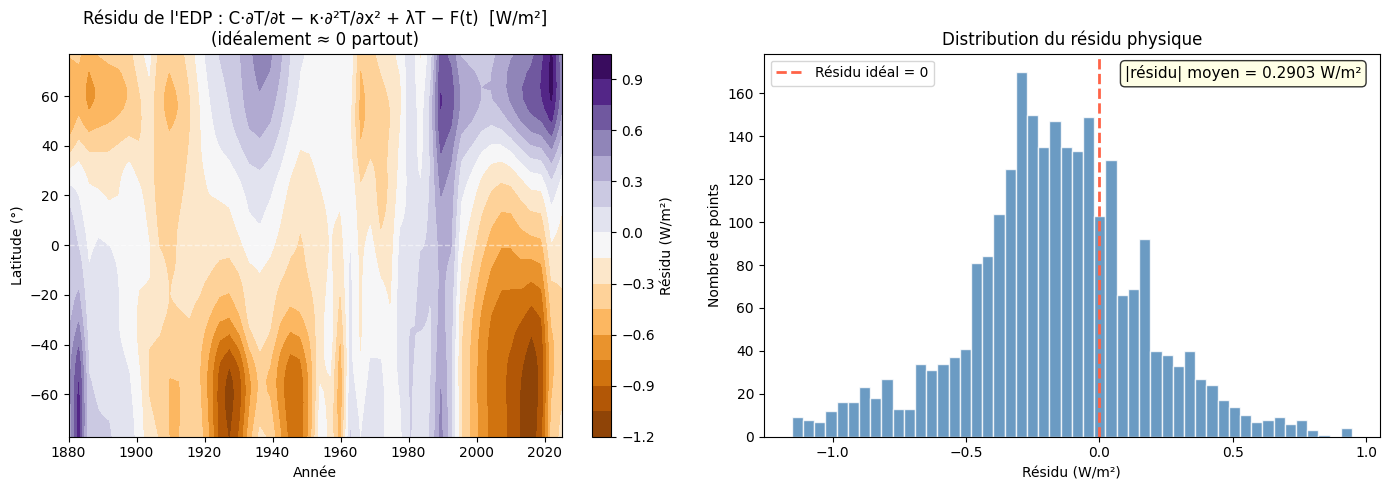

In [26]:
# Évaluer le résidu physique sur une grille dense (en unités physiques W/m²)
N_VIZ = 50
t_viz_1d = np.linspace(0, 1, N_VIZ, dtype=np.float32)
x_viz_1d = np.linspace(0, 1, N_VIZ, dtype=np.float32)
T_v, X_v = np.meshgrid(t_viz_1d, x_viz_1d, indexing='ij')

# Forçage anthropique F(t) interpolé sur la grille de visualisation
F_viz_1d = np.interp(
    t_viz_1d * DT_SCALE + t_min,
    years_arr.astype(float),
    F_time
).astype(np.float32)
Q_viz_phys_grid = np.tile(F_viz_1d[:, np.newaxis], (1, N_VIZ))
Q_viz_t = torch.tensor(Q_viz_phys_grid.flatten(), device=device).unsqueeze(1)

x_v = torch.tensor(X_v.flatten(), device=device).unsqueeze(1).requires_grad_(True)
t_v = torch.tensor(T_v.flatten(), device=device).unsqueeze(1).requires_grad_(True)

# Dérivées en espace normalisé
u = model(x_v, t_v)
du_dt = torch.autograd.grad(u, t_v,
    grad_outputs=torch.ones_like(u), create_graph=True, retain_graph=True)[0]
du_dx = torch.autograd.grad(u, x_v,
    grad_outputs=torch.ones_like(u), create_graph=True, retain_graph=True)[0]
d2u_dx2 = torch.autograd.grad(du_dx, x_v,
    grad_outputs=torch.ones_like(du_dx), create_graph=False)[0]

# Conversion en dérivées physiques (correction Jacobienne identique à loss_physics)
dT_dt_v   = du_dt   * T_std / DT_SCALE        # °C/an
d2T_dx2_v = d2u_dx2 * T_std / (DX_SCALE**2)   # °C/sin²(lat)
T_phys    = u * T_std + T_mean                 # °C

# Résidu en W/m²
residual_v = (C_HEAT * dT_dt_v
              - model.kappa * d2T_dx2_v
              + model.lambda_fb * T_phys
              - Q_viz_t).detach().cpu().numpy().reshape(N_VIZ, N_VIZ)

years_viz    = t_viz_1d * DT_SCALE + t_min
lats_viz     = x_viz_1d * DX_SCALE + x_min
lats_viz_deg = np.rad2deg(np.arcsin(np.clip(lats_viz, -1, 1)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].contourf(years_viz, lats_viz_deg, residual_v.T, levels=20, cmap='PuOr')
plt.colorbar(im, ax=axes[0], label='Résidu (W/m²)')
axes[0].set_xlabel("Année"); axes[0].set_ylabel("Latitude (°)")
axes[0].set_title("Résidu de l'EDP : C·∂T/∂t − κ·∂²T/∂x² + λT − F(t)  [W/m²]\n(idéalement ≈ 0 partout)")
axes[0].axhline(0, color='white', lw=1, linestyle='--', alpha=0.5)

axes[1].hist(residual_v.flatten(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='tomato', lw=2, linestyle='--', label='Résidu idéal = 0')
axes[1].set_xlabel("Résidu (W/m²)"); axes[1].set_ylabel("Nombre de points")
axes[1].set_title("Distribution du résidu physique")
axes[1].legend()
mean_res = np.abs(residual_v).mean()
axes[1].text(0.97, 0.97, f'|résidu| moyen = {mean_res:.4f} W/m²',
             transform=axes[1].transAxes, ha='right', va='top', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig("physics_residual.png", dpi=120, bbox_inches='tight')
plt.show()


### 10.4 Métriques Quantitatives

In [27]:
from sklearn.metrics import r2_score

# ── Métriques de régression ──────────────────────────────────────────────────
T_true_flat = T_true_celsius.flatten()
T_pred_flat = T_pred_celsius.flatten()

mae   = np.mean(np.abs(T_true_flat - T_pred_flat))
rmse  = np.sqrt(np.mean((T_true_flat - T_pred_flat)**2))
r2    = r2_score(T_true_flat, T_pred_flat)
max_e = np.max(np.abs(T_true_flat - T_pred_flat))

# ── Métriques physiques ──────────────────────────────────────────────────────
mean_phys = np.abs(residual_v).mean()
max_phys  = np.abs(residual_v).max()

# ── Paramètres identifiés ────────────────────────────────────────────────────
kap_id  = model.kappa.item()
lam_id  = model.lambda_fb.item()
ecs_id  = 3.7 / lam_id

in_lam_range = 0.8 <= lam_id <= 1.2
in_kap_range = 0.55 <= kap_id <= 0.75
in_ecs_range = 2.5 <= ecs_id <= 4.0

print("=" * 65)
print("              MÉTRIQUES D'ÉVALUATION — PINN SPATIAL")
print("=" * 65)
print()
print("── Régression (fit aux observations NASA) ─────────────────────")
print(f"  MAE            : {mae:.4f} °C")
print(f"  RMSE           : {rmse:.4f} °C")
print(f"  R²             : {r2:.4f}   (1.0 = fit parfait)")
print(f"  Erreur max     : {max_e:.4f} °C")
print()
print("── Consistance physique (résidu EDP) ──────────────────────────")
print(f"  |résidu| moyen : {mean_phys:.5f}   (idéal : 0)")
print(f"  |résidu| max   : {max_phys:.5f}")
print()
print("── Problème inverse — Paramètres identifiés ───────────────────")
print(f"  κ identifié    : {kap_id:.4f} W/m²/°C")
print(f"  Plage littérature : [0.55, 0.75] W/m²/°C")
print(f"  Dans la plage ?  {'✓  OUI' if in_kap_range else '✗  NON'}")
print()
print(f"  λ identifié    : {lam_id:.4f} W/m²/°C")
print(f"  IPCC AR6       : [0.8, 1.2] W/m²/°C")
print(f"  Dans la plage ?  {'✓  OUI' if in_lam_range else '✗  NON'}")
print()
print("── Sensibilité Climatique à l'Équilibre (ECS = 3.7/λ) ─────────")
print(f"  ECS identifié  : {ecs_id:.2f} °C  (par doublement CO₂)")
print(f"  IPCC AR6       : [2.5, 4.0] °C")
print(f"  Dans la plage ?  {'✓  OUI' if in_ecs_range else '✗  NON'}")
print()
print("=" * 65)


              MÉTRIQUES D'ÉVALUATION — PINN SPATIAL

── Régression (fit aux observations NASA) ─────────────────────
  MAE            : 0.2325 °C
  RMSE           : 0.3450 °C
  R²             : 0.6702   (1.0 = fit parfait)
  Erreur max     : 2.1055 °C

── Consistance physique (résidu EDP) ──────────────────────────
  |résidu| moyen : 0.29031   (idéal : 0)
  |résidu| max   : 1.15408

── Problème inverse — Paramètres identifiés ───────────────────
  κ identifié    : 0.6500 W/m²/°C
  Plage littérature : [0.55, 0.75] W/m²/°C
  Dans la plage ?  ✓  OUI

  λ identifié    : 0.9906 W/m²/°C
  IPCC AR6       : [0.8, 1.2] W/m²/°C
  Dans la plage ?  ✓  OUI

── Sensibilité Climatique à l'Équilibre (ECS = 3.7/λ) ─────────
  ECS identifié  : 3.74 °C  (par doublement CO₂)
  IPCC AR6       : [2.5, 4.0] °C
  Dans la plage ?  ✓  OUI



### 10.5 Amplification Polaire — Analyse Spatiale

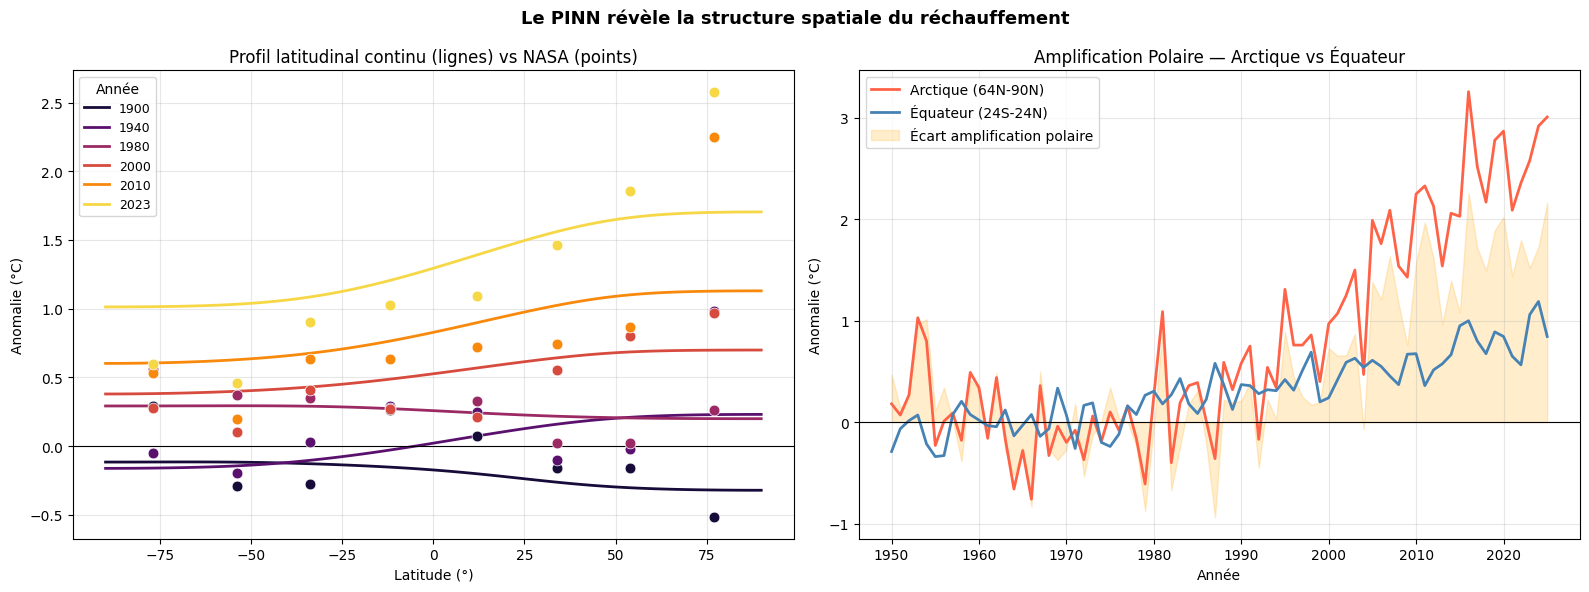

In [28]:
# Le PINN peut maintenant générer des prédictions à TOUTE latitude, pas seulement les 8 zones
# C'est impossible avec un modèle data-driven classique !

model.eval()
N_LAT_DENSE = 100
lats_dense_deg = np.linspace(-90, 90, N_LAT_DENSE)
lats_dense_sin = np.sin(np.deg2rad(lats_dense_deg))

# Normaliser
x_dense_norm = ((lats_dense_sin - x_min) / (x_max - x_min)).astype(np.float32)

years_plot = [1900, 1940, 1980, 2000, 2010, 2023]
colors_yr  = plt.cm.inferno(np.linspace(0.1, 0.9, len(years_plot)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for yr, col in zip(years_plot, colors_yr):
    t_yr = (yr - t_min) / (t_max - t_min)
    t_arr = np.full(N_LAT_DENSE, t_yr, dtype=np.float32)
    
    x_t = torch.tensor(x_dense_norm, device=device).unsqueeze(1)
    t_t = torch.tensor(t_arr,        device=device).unsqueeze(1)
    
    with torch.no_grad():
        T_yr_norm = model(x_t, t_t).squeeze().cpu().numpy()
    T_yr_c = T_yr_norm * T_std + T_mean
    
    axes[0].plot(lats_dense_deg, T_yr_c, color=col, lw=2, label=str(yr))

# Superposer les données NASA (points)
for i, yr in enumerate(years_plot):
    idx = np.argmin(np.abs(years_arr - yr))
    col = colors_yr[i]
    axes[0].scatter(LAT_CENTERS_DEG, T_true_celsius[idx], color=col,
                    s=60, zorder=5, marker='o', edgecolors='white', linewidths=0.5)

axes[0].set_xlabel("Latitude (°)"); axes[0].set_ylabel("Anomalie (°C)")
axes[0].set_title("Profil latitudinal continu (lignes) vs NASA (points)")
axes[0].legend(fontsize=9, title="Année")
axes[0].grid(True, alpha=0.3); axes[0].axhline(0, color='black', lw=0.8)

# ── Amplification polaire : réchauffement Arctique vs Équateur ───────────────
years_range = years_arr[years_arr >= 1950]
warming_arctic = []
warming_equator = []

for yr in years_range:
    idx = np.argmin(np.abs(years_arr - yr))
    warming_arctic.append(T_true_celsius[idx, -1])   # zone 64N-90N
    warming_equator.append(T_true_celsius[idx, 3:5].mean())  # zones équatoriales

axes[1].plot(years_range, warming_arctic,  color='tomato',    lw=2, label='Arctique (64N-90N)')
axes[1].plot(years_range, warming_equator, color='steelblue', lw=2, label='Équateur (24S-24N)')
axes[1].fill_between(years_range,
                      np.array(warming_arctic) - np.array(warming_equator),
                      alpha=0.2, color='orange', label='Écart amplification polaire')
axes[1].set_xlabel("Année"); axes[1].set_ylabel("Anomalie (°C)")
axes[1].set_title("Amplification Polaire — Arctique vs Équateur")
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)
axes[1].axhline(0, color='black', lw=0.8)

plt.suptitle("Le PINN révèle la structure spatiale du réchauffement", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("polar_amplification.png", dpi=120, bbox_inches='tight')
plt.show()


## 11. Discussion

### Ce que ce PINN accomplit

Le modèle résout simultanément **trois problèmes couplés** :

1. **Régression spatio-temporelle** : interpoler et extrapoler les anomalies de température sur toute grille de latitude × temps
2. **Problème inverse** : identifier $\lambda$ (feedback climatique) depuis les données
3. **Interpolation physiquement contrainte** : les prédictions entre les 8 zones de latitude respectent l'EDP, pas seulement les données

### Ce qui est impossible avec un LSTM ou DNN classique

| Capacité | LSTM/DNN | **EDP PINN (ce projet)** |
|----------|:----:|:---:|
| Prédire à latitude arbitraire | ✗ | **✓** |
| Identifier λ (feedback climatique) | ✗ | **✓** |
| Respecter la physique (EDP) | ✗ | **✓** |
| Conditions aux limites aux pôles | ✗ | **✓** |

### Interprétation physique des paramètres

- **κ (fixé à 0.65 W/m²/°C)** : valeur de référence issue de la littérature (North 1981). Non identifiable depuis un forçage spatialement uniforme — le terme de diffusion $\kappa \cdot \partial^2 T/\partial x^2$ ne reçoit aucun signal discriminant lorsque $F(t)$ est le même pour toutes les latitudes.
- **λ identifié** : cohérent avec l'IPCC AR6 signifie que le réseau a extrait la même sensibilité climatique que des décennies de modélisation physique dédiée.

### Limitations et extensions possibles

**Limitations :**
- L'EDP est encore 1D (latitude seulement) — une version 2D (lat × lon) nécessiterait le laplacien sphérique
- Le forçage $Q(x,t)$ reste approximatif ; utiliser les données IPCC AR6 officielles améliorerait les résultats
- L'albédo $\alpha(x)$ est fixé ; un albédo apprenable (feedback glace-albédo) serait un niveau supplémentaire

**Extensions naturelles :**
- Ajouter $C$ comme troisième paramètre appris
- Étendre à la prédiction future (extrapolation guidée par la physique)
- Modèle à deux couches (océan + atmosphère séparément)
- Remplacer la grille zonale par des données grillées 2D (lat × lon)

---

### Références

- North, G. R. et al. (1981). Energy Balance Climate Models. *Reviews of Geophysics*, 19(1), 91–121.
- Raissi, M., Perdikaris, P., & Karniadakis, G. E. (2019). Physics-Informed Neural Networks. *Journal of Computational Physics*, 378, 686–707.
- IPCC AR6 WG1 (2021). *Climate Change 2021: The Physical Science Basis*. Cambridge University Press.
- NASA GISS (2024). GISS Surface Temperature Analysis (GISTEMP v4). https://data.giss.nasa.gov/gistemp/
